In [2]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")

In [3]:
# Set or create an experiment
mlflow.set_experiment("ML Algos with HP Tuning")

<Experiment: artifact_location=('file:c:/Users/Soham/Documents/youtube comment '
 'analyzer/mlruns/901947899065852447'), creation_time=1778952120616, experiment_id='901947899065852447', last_update_time=1778952120616, lifecycle_stage='active', name='ML Algos with HP Tuning', tags={}, trace_location=None, workspace='default'>

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import optuna

In [5]:
df = pd.read_csv('reddit_preprocessing.csv').dropna()
df.shape

(36662, 2)

[I 2026-05-17 16:40:28,384] A new study created in memory with name: no-name-1d5fa191-85a0-47b1-a0ab-c93d07eff053


[I 2026-05-17 16:46:05,313] Trial 0 finished with value: 0.1974814160042805 and parameters: {'C': 0.005165807570871529, 'kernel': 'linear'}. Best is trial 0 with value: 0.1974814160042805.
[I 2026-05-17 16:49:43,802] Trial 1 finished with value: 0.7749882284561246 and parameters: {'C': 0.20273803960446077, 'kernel': 'linear'}. Best is trial 1 with value: 0.7749882284561246.
[I 2026-05-17 16:55:24,803] Trial 2 finished with value: 0.35472371823245635 and parameters: {'C': 0.01798000419354878, 'kernel': 'rbf'}. Best is trial 1 with value: 0.7749882284561246.
[I 2026-05-17 17:13:39,012] Trial 3 finished with value: 0.5447631492860255 and parameters: {'C': 0.8959695304378477, 'kernel': 'poly'}. Best is trial 1 with value: 0.7749882284561246.
[I 2026-05-17 17:28:11,622] Trial 4 finished with value: 0.8133608705954701 and parameters: {'C': 4.683243149599683, 'kernel': 'rbf'}. Best is trial 4 with value: 0.8133608705954701.
[I 2026-05-17 17:38:43,872] Trial 5 finished with value: 0.2480576587

BEST PARAMETERS
{'C': 1.5394930738608525, 'kernel': 'linear'}
Accuracy    : 0.8546
Macro F1    : 0.8427
Weighted F1 : 0.8543

Classification Report:

              precision    recall  f1-score   support

          -1       0.75      0.78      0.76      1650
           0       0.86      0.95      0.90      2529
           1       0.92      0.82      0.86      3154

    accuracy                           0.85      7333
   macro avg       0.84      0.85      0.84      7333
weighted avg       0.86      0.85      0.85      7333



2026/05/17 19:43:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   Kernel         C  Accuracy  Macro_F1  Weighted_F1
0  linear  1.539493   0.85463  0.842729     0.854302


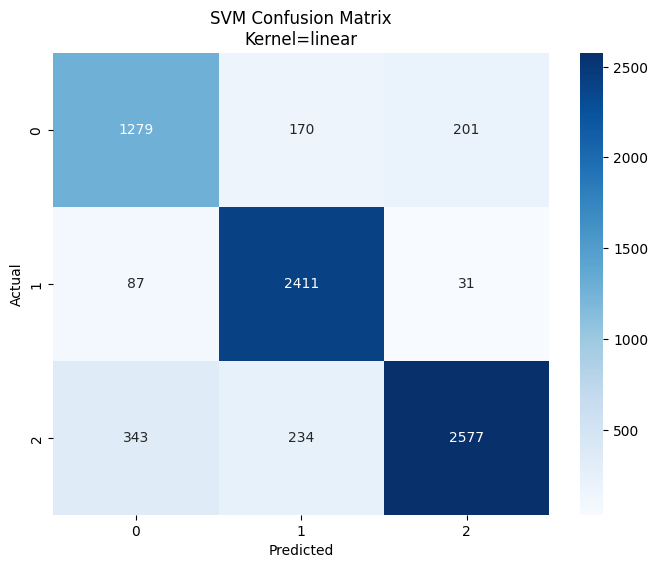

In [6]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import optuna
import mlflow

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# RANDOM SEED
# =========================================================
np.random.seed(42)

# =========================================================
# MLFLOW EXPERIMENT
# =========================================================
mlflow.set_experiment(
    "SVM_Kernel_Comparison"
)

# =========================================================
# REMOVE NaN TARGETS
# =========================================================
df = df.dropna(
    subset=['category']
)

# =========================================================
# FEATURES / TARGET
# =========================================================
X_text = df['clean_comment']

y = df['category']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train_text, X_test_text, y_train, y_test = train_test_split(

    X_text,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# =========================================================
# TF-IDF SETTINGS
# =========================================================
ngram_range = (1, 3)

max_features = 5000

# =========================================================
# CROSS VALIDATION
# =========================================================
cv = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=42
)

# =========================================================
# RESULTS STORAGE
# =========================================================
results = []

# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================
def objective_svm(trial):

    params = {

        "C": trial.suggest_float(
            'C',
            1e-3,
            10.0,
            log=True
        ),

        "kernel": trial.suggest_categorical(
            'kernel',
            ['linear', 'rbf', 'poly']
        ),

        "class_weight": "balanced",

        "random_state": 42
    }

    # =====================================================
    # PIPELINE
    # =====================================================
    pipeline = Pipeline([

        (
            "tfidf",

            TfidfVectorizer(

                ngram_range=ngram_range,

                max_features=max_features,

                min_df=3,

                max_df=0.90,

                sublinear_tf=True
            )
        ),

        (
            "model",

            SVC(
                **params
            )
        )
    ])

    # =====================================================
    # CROSS VALIDATION
    # =====================================================
    scores = cross_val_score(

        pipeline,

        X_train_text,

        y_train,

        cv=cv,

        scoring='f1_macro',

        n_jobs=1
    )

    return np.mean(scores)

# =========================================================
# RUN OPTUNA
# =========================================================
study = optuna.create_study(
    direction="maximize"
)

study.optimize(

    objective_svm,

    n_trials=20
)

# =========================================================
# BEST PARAMETERS
# =========================================================
print("=" * 60)

print("BEST PARAMETERS")

print(study.best_params)

print("=" * 60)

# =========================================================
# FINAL PIPELINE
# =========================================================
best_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            ngram_range=ngram_range,

            max_features=max_features,

            min_df=3,

            max_df=0.90,

            sublinear_tf=True
        )
    ),

    (
        "model",

        SVC(

            C=study.best_params['C'],

            kernel=study.best_params['kernel'],

            class_weight='balanced',

            random_state=42
        )
    )
])

# =========================================================
# TRAIN FINAL MODEL
# =========================================================
best_pipeline.fit(

    X_train_text,

    y_train
)

# =========================================================
# PREDICTIONS
# =========================================================
y_pred = best_pipeline.predict(
    X_test_text
)

# =========================================================
# METRICS
# =========================================================
accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(

    y_test,

    y_pred,

    average='macro'
)

weighted_f1 = f1_score(

    y_test,

    y_pred,

    average='weighted'
)

# =========================================================
# STORE RESULTS
# =========================================================
results.append({

    "Kernel": study.best_params['kernel'],

    "C": study.best_params['C'],

    "Accuracy": accuracy,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1
})

# =========================================================
# RESULTS
# =========================================================
print(f"Accuracy    : {accuracy:.4f}")

print(f"Macro F1    : {macro_f1:.4f}")

print(f"Weighted F1 : {weighted_f1:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================
conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(

    conf_matrix,

    annot=True,

    fmt='d',

    cmap='Blues',

    ax=ax
)

ax.set_xlabel("Predicted")

ax.set_ylabel("Actual")

ax.set_title(

    f"SVM Confusion Matrix\nKernel={study.best_params['kernel']}"
)

# =========================================================
# MLFLOW LOGGING
# =========================================================
with mlflow.start_run(

    run_name=f"SVM_{study.best_params['kernel']}"
):

    # -----------------------------------------------------
    # TAGS
    # -----------------------------------------------------
    mlflow.set_tag(
        "model",
        "SVM"
    )

    mlflow.set_tag(
        "vectorizer",
        "TF-IDF"
    )

    mlflow.set_tag(
        "kernel",
        study.best_params['kernel']
    )

    # -----------------------------------------------------
    # PARAMETERS
    # -----------------------------------------------------
    mlflow.log_param(
        "ngram_range",
        ngram_range
    )

    mlflow.log_param(
        "max_features",
        max_features
    )

    mlflow.log_params(
        study.best_params
    )

    # -----------------------------------------------------
    # METRICS
    # -----------------------------------------------------
    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.log_metric(
        "macro_f1",
        macro_f1
    )

    mlflow.log_metric(
        "weighted_f1",
        weighted_f1
    )

    # -----------------------------------------------------
    # CLASSIFICATION REPORT
    # -----------------------------------------------------
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    for label, metrics in report.items():

        if isinstance(metrics, dict):

            for metric_name, metric_value in metrics.items():

                mlflow.log_metric(
                    f"{label}_{metric_name}",
                    metric_value
                )

    # -----------------------------------------------------
    # CONFUSION MATRIX
    # -----------------------------------------------------
    mlflow.log_figure(
        fig,
        f"svm_confusion_matrix_{study.best_params['kernel']}.png"
    )

    # -----------------------------------------------------
    # SAVE MODEL
    # -----------------------------------------------------
    mlflow.sklearn.log_model(

        sk_model=best_pipeline,

        name="svm_pipeline"
    )

# =========================================================
# COMPARISON DATAFRAME
# =========================================================
results_df = pd.DataFrame(results)

print(results_df)

plt.show()

plt.close(fig)